In [1]:
%pip install networkx matplotlib pandas tqdm gcastle torch pgmpy ipywidgets

Note: you may need to restart the kernel to use updated packages.


In [2]:
from castle.common import GraphDAG
from castle.datasets import IIDSimulation, DAG
import pandas as pd
import random
import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# gera um DAG aleatório com pesos
weighted_random_dag = DAG.erdos_renyi(n_nodes=20, n_edges=80, weight_range=(0.5, 2.0), seed=1)

# gera um dataset a partir do DAG
# dataset = IIDSimulation(W=weighted_random_dag, n=1000, method='linear', sem_type='gauss') # linear: X = W @ X + noise
dataset = IIDSimulation(W=weighted_random_dag, n=1000, method='nonlinear', sem_type='mlp') # nonlinear: X = W @ mlp(X) + noise
true_causal_matrix, X = dataset.B, dataset.X

df_X = pd.DataFrame(X, columns=[f'X{i}' for i in range(X.shape[1])])
df_X.head()

2026-04-25 01:11:45,869 - /home/luis/Documents/projects/genetic_causal_graph/.venv/lib/python3.12/site-packages/castle/datasets/simulator.py[line:270] - INFO: Finished synthetic dataset


,X0,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12,X13,X14,X15,X16,X17,X18,X19
0,-4.502411,13.836179,-3.658511,-7.658265,-8.600025,-11.124509,-5.549516,1.482765,-11.176317,3.930890,2.706370,-7.746698,14.658194,4.876467,6.698385,-9.472170,19.831624,10.332202,1.105082,4.833849
1,-6.514873,15.588579,-2.321086,-8.413341,-7.709850,-9.556385,-9.504243,2.242367,-8.648973,6.619765,1.567403,-7.575218,14.147558,3.933992,4.957334,-8.817838,15.483988,9.564645,1.487900,-1.613710
2,-2.111840,15.569914,-1.929396,-9.445322,-3.899252,0.928045,2.278290,-2.570958,-0.614064,6.710153,0.427376,-7.056613,14.634008,-0.269541,4.873208,-10.205134,18.523175,9.891275,0.131874,5.443409
3,-6.929572,13.421795,-3.014977,-3.799500,-1.541067,-3.226148,4.087347,-7.513306,2.028193,3.906634,-1.042532,-5.952216,14.006139,1.747810,5.437411,-10.542286,15.780495,9.117086,-0.468346,4.468650
4,-5.101315,10.281860,-3.300231,-8.126094,0.075928,3.508589,7.335281,-6.858379,6.465580,1.709765,-0.602114,-3.453220,14.043727,-0.708839,3.894073,-6.861490,12.523290,11.377821,-1.247737,6.952089


2026-04-25 01:11:47,712 - /home/luis/Documents/projects/genetic_causal_graph/.venv/lib/python3.12/site-packages/castle/backend/__init__.py[line:36] - INFO: You can use `os.environ['CASTLE_BACKEND'] = backend` to set the backend(`pytorch` or `mindspore`).
2026-04-25 01:11:47,755 - /home/luis/Documents/projects/genetic_causal_graph/.venv/lib/python3.12/site-packages/castle/algorithms/__init__.py[line:36] - INFO: You are using ``pytorch`` as the backend.


Gerando grafo PC


2026-04-25 01:11:48,071 - /home/luis/Documents/projects/genetic_causal_graph/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:195] - INFO: [start]: n=1000, d=20, iter_=100, h_=1e-08, rho_=1e+16
2026-04-25 01:11:48,261 - /home/luis/Documents/projects/genetic_causal_graph/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:206] - INFO: [iter 0] h=5.389e-01, loss=77.438, rho=1.0e+00


Tempo de execução do PC: 0.0051496942838033044 min 
Gerando grafo Notears


2026-04-25 01:11:48,308 - /home/luis/Documents/projects/genetic_causal_graph/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:206] - INFO: [iter 1] h=4.197e-01, loss=24.227, rho=1.0e+00
2026-04-25 01:11:48,378 - /home/luis/Documents/projects/genetic_causal_graph/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:206] - INFO: [iter 1] h=2.380e-01, loss=25.534, rho=1.0e+01
2026-04-25 01:11:48,460 - /home/luis/Documents/projects/genetic_causal_graph/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:206] - INFO: [iter 1] h=9.682e-02, loss=38.600, rho=1.0e+02
2026-04-25 01:11:48,532 - /home/luis/Documents/projects/genetic_causal_graph/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:206] - INFO: [iter 2] h=6.261e-02, loss=26.432, rho=1.0e+02
2026-04-25 01:11:48,639 - /home/luis/Documents/projects/genetic_causal_graph/.venv/lib/python3.12/site-packages/

Tempo de execução do Notears: 0.2488212744394938 min 
Gerando grafo Genetic Discovery
Generation 1: Best Fitness = -9322.271897533936
Generation 2: Best Fitness = -9322.271897533936
Generation 3: Best Fitness = -9322.271897533936
Generation 4: Best Fitness = -9322.271897533936
Generation 5: Best Fitness = -9322.271897533936
Generation 6: Best Fitness = -9322.271897533936
Generation 7: Best Fitness = -9322.271897533936
Generation 8: Best Fitness = -9322.271897533936
Generation 9: Best Fitness = -9322.271897533936
Generation 10: Best Fitness = -9322.271897533936
Generation 11: Best Fitness = -9322.271897533936
Generation 12: Best Fitness = -9322.271897533936
Generation 13: Best Fitness = -9322.271897533936
Generation 14: Best Fitness = -9322.271897533936
Generation 15: Best Fitness = -9322.271897533936
Generation 16: Best Fitness = -9322.271897533936
Generation 17: Best Fitness = -9198.894250255778
Generation 18: Best Fitness = -9198.894250255778
Generation 19: Best Fitness = -9198.89425

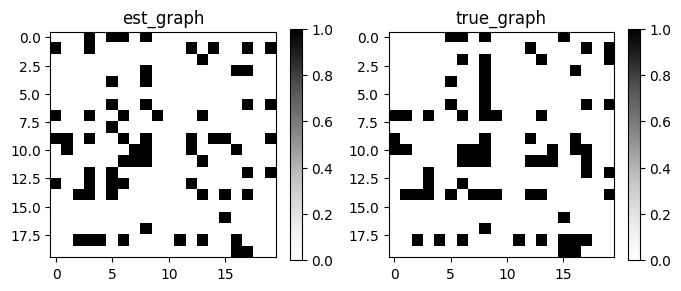

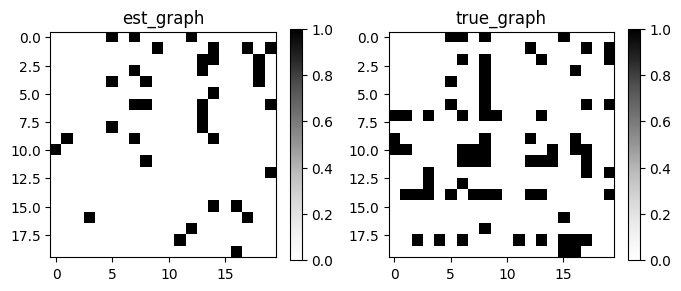

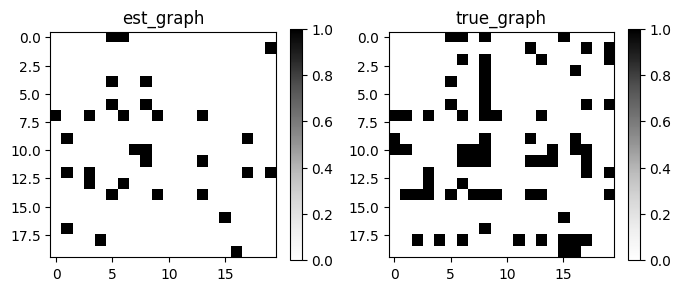

In [3]:
import time
from castle.algorithms import PC, Notears, GES
from genetic_discovery.main import genetic_discovery


print("Gerando grafo PC")
time_start = time.time()
pc = PC()
pc.learn(X)
time_end = time.time()
print(f"Tempo de execução do PC: {(time_end - time_start) / 60} min ")


print("Gerando grafo Notears")
time_start = time.time()
notears = Notears()
notears.learn(X)
time_end = time.time()
print(f"Tempo de execução do Notears: {(time_end - time_start) / 60} min ")

#print("Gerando grafo GES")
#time_start = time.time()
#ges = GES()
#ges.learn(X)
#time_end = time.time()
#print(f"Tempo de execução do GES: {(time_end - time_start) / 60} min ")

print("Gerando grafo Genetic Discovery")
time_start = time.time()
initial_population = [pc.causal_matrix, notears.causal_matrix] #, ges.causal_matrix]
pop_size = 500 
best_dag = genetic_discovery(X, n_nodes=pc.causal_matrix.shape[0], matrix_initial_pop=initial_population, num_generations=1000, population_size=pop_size, num_parents_mating=int(pop_size*0.5), mutation_rate=0.2)
time_end = time.time()
print(f"Tempo de execução do Genetic Discovery: {(time_end - time_start) / 60} min ")



GraphDAG(best_dag, true_causal_matrix, 'result')
GraphDAG(pc.causal_matrix, true_causal_matrix, 'result')
GraphDAG(notears.causal_matrix, true_causal_matrix, 'result')
#GraphDAG(ges.causal_matrix, true_causal_matrix, 'result')


In [4]:
import networkx as nx
# verifica se os grafos são DAGs
print("Best DAG é um DAG?", nx.is_directed_acyclic_graph(nx.DiGraph(best_dag)))
print("PC é um DAG?", nx.is_directed_acyclic_graph(nx.DiGraph(pc.causal_matrix)))
print("Notears é um DAG?", nx.is_directed_acyclic_graph(nx.DiGraph(notears.causal_matrix)))

Best DAG é um DAG? True
PC é um DAG? False
Notears é um DAG? True


In [5]:
import numpy as np
import pandas as pd
from castle.metrics import MetricsDAG

true_bin = true_causal_matrix

predictions = {
    "Genetic Discovery": best_dag,
    "PC": pc.causal_matrix,
    "Notears": notears.causal_matrix,
    #"GES": ges.causal_matrix,
}

metrics_table = {}
for method, pred in predictions.items():
    metrics_table[method] = MetricsDAG(true_bin, pred).metrics

df_metrics = pd.DataFrame(metrics_table).T
display(df_metrics.round(4))

,fdr,tpr,fpr,shd,nnz,precision,recall,F1,gscore
Genetic Discovery,0.3288,0.7000,0.2000,42.0,73.0,0.6712,0.7000,0.6853,0.3571
PC,0.8082,0.3784,0.3856,65.0,73.0,0.1918,0.3784,0.2545,0.0000
Notears,0.6301,0.8710,0.2893,48.0,73.0,0.3699,0.8710,0.5192,0.0000
